In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/product_sales_dataset_final.csv')
df.head()

,Order_ID,Order_Date,Customer_Name,City,State,Region,Country,Category,Sub_Category,Product_Name,Quantity,Unit_Price,Revenue,Profit
0,1,08-23-23,Bianca Brown,Jackson,Mississippi,South,United States,Accessories,Small Electronics,Phone Case,3,201.01,603.03,221.49
1,2,12-20-24,Jared Edwards,Grand Rapids,Michigan,Centre,United States,Accessories,Small Electronics,Charging Cable,4,74.30,297.20,97.09
2,3,01-29-24,Susan Valdez,Minneapolis,Minnesota,Centre,United States,Clothing & Apparel,Sportswear,Nike Air Force 1,1,68.19,68.19,25.47
3,4,11-29-24,Tina Williams,Tallahassee,Florida,South,United States,Clothing & Apparel,Sportswear,Adidas Tracksuit,3,209.64,628.92,231.38
4,5,09-21-23,Catherine Gordon,Baltimore,Maryland,East,United States,Accessories,Bags,Backpack,1,216.63,216.63,42.46


In [28]:
# Fix date format so SQL can read it correctly
df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='%m-%d-%y')

# Check the result
print(df['Order_Date'].dtype)
df['Order_Date'].head()

datetime64[ns]


,Order_Date
0,2023-08-23
1,2024-12-20
2,2024-01-29
3,2024-11-29
4,2023-09-21


In [29]:
# Install DuckDB — run once
!pip install duckdb -q

import duckdb

# Find each customer's first purchase month
first_purchase = duckdb.sql("""
    SELECT
        Customer_Name,
        MIN(DATE_TRUNC('month', Order_Date)) AS cohort_month
    FROM df
    GROUP BY Customer_Name
    ORDER BY cohort_month
""").df()

first_purchase.head(10)

,Customer_Name,cohort_month
0,Kathy Wilson,2023-01-01
1,Lauren Morrow,2023-01-01
2,Christine Diaz,2023-01-01
3,Mark Davis,2023-01-01
4,Matthew Russell,2023-01-01
5,Samantha Martinez,2023-01-01
6,Joseph Farmer,2023-01-01
7,John Hunter,2023-01-01
8,Joseph Garcia,2023-01-01
9,Christopher Edwards,2023-01-01


In [30]:
cohort_data = duckdb.sql("""
    SELECT
        fp.cohort_month,
        DATEDIFF('month', fp.cohort_month, DATE_TRUNC('month', d.Order_Date)) AS month_number,
        COUNT(DISTINCT d.Customer_Name) AS customers
    FROM df d
    JOIN first_purchase fp
        ON d.Customer_Name = fp.Customer_Name
    GROUP BY fp.cohort_month, month_number
    ORDER BY fp.cohort_month, month_number
""").df()

cohort_data.head(15)

,cohort_month,month_number,customers
0,2023-01-01,0,5893
1,2023-01-01,1,274
2,2023-01-01,2,367
3,2023-01-01,3,386
4,2023-01-01,4,464
5,2023-01-01,5,449
6,2023-01-01,6,426
7,2023-01-01,7,419
8,2023-01-01,8,425
9,2023-01-01,9,713


In [31]:
# Calculate retention rate as % of cohort size
cohort_pivot = cohort_data.pivot_table(
    index='cohort_month',
    columns='month_number',
    values='customers'
)

cohort_size = cohort_pivot[0]
retention = cohort_pivot.divide(cohort_size, axis=0) * 100
retention = retention.round(1)
retention.index = retention.index.strftime('%Y-%m')

retention.iloc[:6, :7]  # preview: 6 cohorts, 7 months

month_number,0,1,2,3,4,5,6
cohort_month,,,,,,,
2023-01,100.0,4.6,6.2,6.6,7.9,7.6,7.2
2023-02,100.0,5.0,5.8,6.7,5.9,5.9,5.3
2023-03,100.0,5.1,5.8,5.8,4.7,5.2,5.1
2023-04,100.0,4.3,4.5,4.4,4.0,4.4,8.2
2023-05,100.0,4.3,3.4,3.7,4.0,7.3,11.0
2023-06,100.0,3.8,3.5,3.8,6.2,9.8,7.8


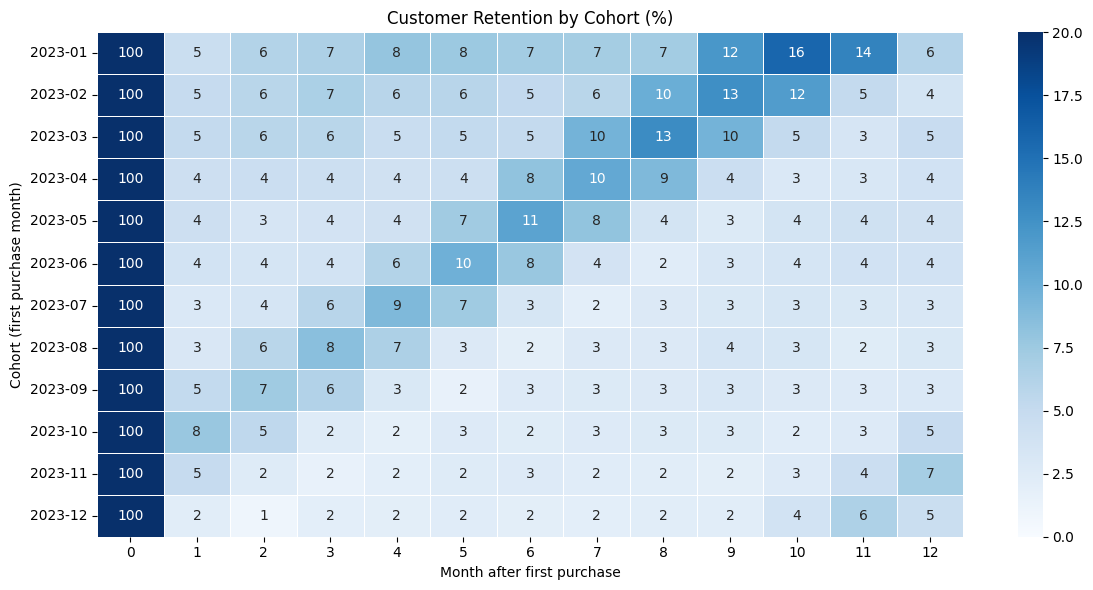

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot retention heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(
    retention.iloc[:12, :13],
    annot=True,
    fmt='.0f',
    cmap='Blues',
    vmin=0, vmax=20,
    linewidths=0.5
)
plt.title('Customer Retention by Cohort (%)')
plt.xlabel('Month after first purchase')
plt.ylabel('Cohort (first purchase month)')
plt.tight_layout()
plt.savefig('cohort_heatmap.png', dpi=150)
plt.show()

## Business Insights

### Key findings

**1. Low overall retention (4-5% in M+1)**

Only 4-5 out of 100 customers return the month after their first purchase.
The store is good at acquiring new customers but struggles to retain them long-term.

**2. January 2023 cohort stands out (16% retention at M+10)**

Customers acquired in January show the highest long-term loyalty.

Worth investigating: was there a different promotion or product mix that month?
If replicated, this could improve retention across all cohorts.

**3. Diagonal pattern = seasonal effect (Black Friday / Christmas)**

Customers from different cohorts all return at the same calendar moment — October/November.
The store has a strong seasonal magnet but lacks a mechanism to keep customers
returning regularly throughout the year. A loyalty program could help solve this.

**4. December 2023 cohort has the lowest retention (1-2%)**

Customers acquired in December (likely through Christmas promotions) are the least loyal.
They come for the deal and don't come back.

### Recommendations
- Retention efforts should focus on the M+1 window, because that is where the biggest drop-off happens
- The January 2023 cohort is worth investigating to understand what drove
  higher loyalty that month
- A loyalty program could help smooth out the seasonal spikes and encourage
  more regular purchases throughout the year
- Customers who remain active beyond M+3 generate the highest long-term value, so it is worth investing in keeping them engaged